### Rotation Embeddings

Resource:
https://krasserm.github.io/2022/12/13/rotary-position-embedding/

In [6]:
import torch
from einops import rearrange, repeat

import matplotlib.pyplot as plt

In [3]:

# Frequency position encoding:
# Precomputes sin and cos in EQN 12
def freq_pos_enc(dim, max_seq_len):
    # inverse frequencies [theta_1, theta_2, ..., theta_dim/2]
    inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2, dtype=torch.float) / dim))  # (dim/2,)
    # positions up to max_seq_len
    pos = torch.arange(max_seq_len)  # (max_seq_len,)
    # frequency position encoding (outer product: pos x inv_freq)
    pos_enc = torch.einsum("p, f -> p f", pos, inv_freq)  # (max_seq_len, dim/2)
    # duplicate each element along inverse frequency dimension
    return repeat(pos_enc, "... f -> ... (f r)", r=2)  # (max_seq_len, dim)


# Helper to shuffle elements of u
def rotate_half(u):
    # last dimension of u is [u1, u2, u3, u4, ...]
    u = rearrange(u, '... (d r) -> ... d r', r=2)
    u1, u2 = u.unbind(dim=-1)
    u = torch.stack((-u2, u1), dim=-1)
    # last dimension of result is [-u2, u1, -u4, u3, ...]
    return rearrange(u, '... d r -> ... (d r)')


# Rotation of u given a frequency position encoding can be implemented as:
def rotate(u, pos_enc):
    num_tokens = u.shape[-2]
    pos_enc = pos_enc[:num_tokens]
    return u * pos_enc.cos() + (rotate_half(u) * pos_enc.sin())


In [9]:
batch_size = 2
num_heads = 8
seq_len = 64
head_dim = 32
max_seq_len = 512

# random queries and keys
q = torch.randn(batch_size, num_heads, seq_len, head_dim)
k = torch.randn(batch_size, num_heads, seq_len, head_dim)

# frequency-encode positions 1 - 512
pos_enc = freq_pos_enc(dim=head_dim, max_seq_len=max_seq_len)

# encode absolute positions into queries and keys
q_rot = rotate(q, pos_enc)
k_rot = rotate(k, pos_enc)

# take inner product of queries and keys to obtain attention
# matrices that have relative position information encoded
attn = torch.einsum("b h i c, b h j c -> b h i j", q_rot, k_rot)
assert attn.shape == (batch_size, num_heads, seq_len, seq_len)

In [12]:
print(f"head_dim: {head_dim}")
print(f"seq_len: {seq_len}")
print(f"max_seq_len: {max_seq_len}")
print(f"pos_enc.shape: {pos_enc.shape}")

head_dim: 32
seq_len: 64
max_seq_len: 512
pos_enc.shape: torch.Size([512, 32])


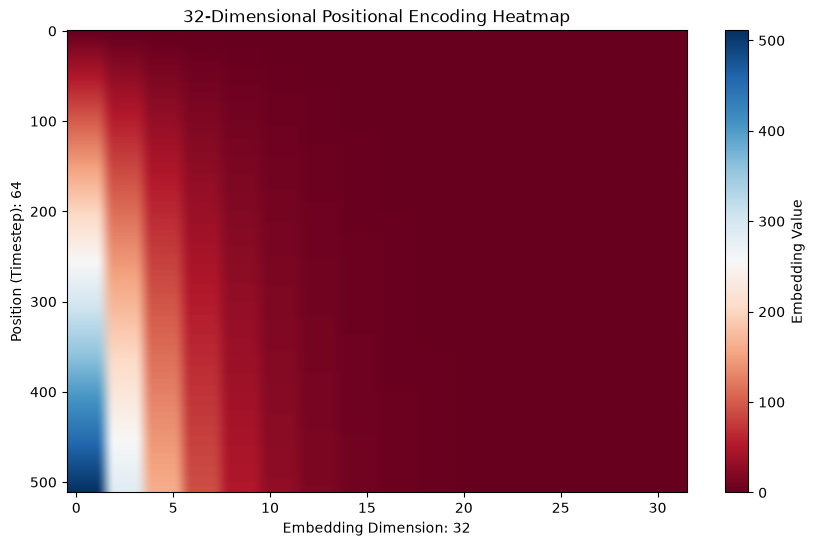

In [11]:
# Plot Heatmap
plt.figure(figsize=(10, 6))
plt.imshow(pos_enc.cpu().numpy(), aspect="auto", cmap="RdBu")
plt.colorbar(label="Embedding Value")
plt.title("{0}-Dimensional Positional Encoding Heatmap".format(head_dim))
plt.xlabel("Embedding Dimension: {0}".format(head_dim))
plt.ylabel("Position (Timestep): {0}".format(seq_len))
plt.show()